# Evaluación Parcial N°3

## Programación en Ciencia de Datos - Proyecto End to End

**Asignatura:** SCY1101_002D Programación en Ciencia de Datos  
**Estudiante:** Fabian Quiñones  
**Dataset utilizado:** `dataset_car_seats.csv` + API `mindicador.cl`  
**Caso:** Car Seats  
**Variable objetivo:** `Sales`

---

## 1. Introducción del proyecto

En este proyecto se trabaja con información relacionada a la venta de sillas para autos infantiles en distintas tiendas. El objetivo principal es analizar los factores que pueden influir en las ventas (`Sales`) y construir modelos predictivos que permitan estimar su comportamiento a partir de variables como precio, publicidad, ingreso de la zona, población, edad, educación, ubicación del producto en estantería y características del mercado.

El proyecto integra dos fuentes de información: el archivo CSV del dataset CarSeats y una API externa utilizada para obtener el valor del dólar. Esto permite adaptar las variables monetarias al contexto chileno, trabajando con valores expresados en pesos chilenos dentro del DataFrame `df_clp`.


## 2. Arquitecturas evaluadas

Antes de desarrollar el flujo de ciencia de datos, se consideran tres enfoques de arquitectura: **Data Lake**, **Lakehouse** y **Pipeline Híbrido Modular**.

| Arquitectura | Descripción | Relación con el proyecto |
|---|---|---|
| **Data Lake** | Permite almacenar grandes volúmenes de datos crudos y variados. | No es la opción principal porque este proyecto no busca construir una plataforma de almacenamiento masivo, sino procesar y analizar un dataset específico. |
| **Lakehouse** | Combina la flexibilidad del Data Lake con la organización de un Data Warehouse. | Puede ser útil en escenarios empresariales de mayor escala, pero resulta más amplio de lo necesario para este caso. |
| **Pipeline Híbrido Modular** | Organiza el trabajo en módulos conectados, desde la ingesta de datos hasta la visualización final. | Es el enfoque más adecuado porque el proyecto combina CSV, API, transformación de datos, análisis exploratorio, modelos predictivos y dashboard. |


## 3. Arquitectura seleccionada: Pipeline Híbrido Modular

Para este proyecto se selecciona la arquitectura **Pipeline Híbrido Modular**, ya que se adapta mejor al objetivo del trabajo: desarrollar un flujo completo de ciencia de datos desde la obtención de datos hasta la presentación de resultados.

Esta arquitectura es **híbrida** porque integra más de una fuente de datos:

- El archivo CSV del dataset CarSeats.
- Una API externa utilizada para obtener el valor del dólar y convertir variables monetarias a pesos chilenos.

También es **modular** porque divide el proyecto en etapas independientes y conectadas entre sí. Esto permite revisar, corregir o mejorar una parte del proceso sin afectar necesariamente todo el proyecto.

El flujo aplicado será:

```text
CSV CarSeats + API tipo de cambio
        ↓
Módulo 1: Ingesta de datos
        ↓
Módulo 2: Transformación y limpieza
        ↓
Módulo 3: Análisis exploratorio
        ↓
Módulo 4: Preprocesamiento para modelamiento
        ↓
Módulo 5: Modelamiento predictivo
        ↓
Módulo 6: Evaluación de modelos
        ↓
Módulo 7: Visualización mediante dashboard
        ↓
Conclusión del proyecto
```

A diferencia de un Data Lake o un Lakehouse, este enfoque no se centra principalmente en almacenar grandes volúmenes de datos, sino en ordenar el proceso completo de análisis, predicción y visualización.


## 4. Preparación del entorno e importaciones

En esta sección se importan las librerías necesarias para la carga de datos, consumo de API, visualización, modelamiento predictivo y construcción del dashboard.

In [86]:
# Si Dash no está instalado, descomenta y ejecuta esta línea:
!pip install dash -q

In [87]:
# Manejo de datos
import pandas as pd
import numpy as np

# Rutas y archivos
from pathlib import Path

# API
import requests

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import StrMethodFormatter

# Dashboard con Dash
from dash import Dash, dcc, html, Input, Output
from google.colab import output

# Machine Learning - preparación y pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelo predictivo seleccionado
from sklearn.ensemble import RandomForestRegressor

# Métricas de regresión
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Mostrar texto dinámico en el notebook
from IPython.display import Markdown, display

# Evitar warnings molestos
import warnings
warnings.filterwarnings("ignore")

# Paleta de colores para gráficos interactivos
# Inspirada en el notebook revisado en clases
colores_dashboard = ["#ADA2FF", "#C0DEFF", "#FCDDB0", "#FF9F9F", "#EDD2F3"]


## 5. Módulo 1: Ingesta de datos

Este módulo corresponde a la entrada de información al pipeline. En este proyecto se utilizan dos fuentes:

1. Un archivo CSV con el dataset CarSeats.
2. Una API externa (`mindicador.cl`) para obtener el valor del dólar.

Estas fuentes permiten iniciar el flujo híbrido del proyecto.

In [88]:
# Lectura del archivo CSV

ruta_csv = Path("dataset_car_seats.csv")

# Ruta alternativa por si el archivo se encuentra en una carpeta data/raw
if not ruta_csv.exists():
    ruta_csv = Path("../data/raw/dataset_car_seats.csv")

df = pd.read_csv(ruta_csv)

print("Dimensiones del DataFrame original:", df.shape)
df.head()

Dimensiones del DataFrame original: (400, 12)


,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [89]:
# Consumo de API para obtener el valor del dólar
# Se utiliza try/except para manejar errores de conexión o problemas con la respuesta de la API.

url_api = "https://mindicador.cl/api"
valor_dolar_respaldo = 900  # Valor de respaldo para que el notebook pueda continuar si falla la API

try:
    respuesta = requests.get(url_api, timeout=10)
    respuesta.raise_for_status()
    datos_api = respuesta.json()

    valor_dolar = datos_api["dolar"]["valor"]
    fecha_dolar = datos_api["dolar"]["fecha"]

    print("API consultada correctamente.")

except requests.exceptions.RequestException as error:
    print("No se pudo conectar correctamente con la API.")
    print("Detalle del error:", error)
    valor_dolar = valor_dolar_respaldo
    fecha_dolar = "No disponible: se usa valor de respaldo"

except (KeyError, ValueError) as error:
    print("La API respondió, pero el formato de los datos no era el esperado.")
    print("Detalle del error:", error)
    valor_dolar = valor_dolar_respaldo
    fecha_dolar = "No disponible: se usa valor de respaldo"

print("Valor del dólar utilizado:", valor_dolar)
print("Fecha del valor:", fecha_dolar)


Valor del dólar observado: 905.78
Fecha del valor: 2026-06-23T04:00:00.000Z


### Manejo de errores en la API

El consumo de la API se realiza dentro de un bloque `try/except`. Si la conexión falla o la respuesta no tiene el formato esperado, el notebook utiliza un valor de respaldo para continuar con el flujo del Pipeline Híbrido Modular. En un proyecto real, este valor debería actualizarse manualmente o reemplazarse por otra fuente confiable.

In [90]:
# Se crea una copia para trabajar sin modificar el DataFrame original

df_clp = df.copy()

# Si existe una columna de índice importada desde el CSV, se elimina
if "Unnamed: 0" in df_clp.columns:
    df_clp = df_clp.drop(columns=["Unnamed: 0"])

df_clp.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


## 6. Módulo 2: Transformación y limpieza de datos

En este módulo se adaptan los datos al contexto del proyecto. Las variables monetarias se convierten a pesos chilenos usando el valor del dólar obtenido desde la API.

Se mantiene `Sales` como variable numérica continua, ya que será la variable objetivo del modelo predictivo.

In [91]:
# Conversión de variables monetarias a pesos chilenos dentro de df_clp

# Price y CompPrice vienen expresadas en dólares directos
df_clp["Price"] = (df_clp["Price"] * valor_dolar).round(0).astype(int)
df_clp["CompPrice"] = (df_clp["CompPrice"] * valor_dolar).round(0).astype(int)

# Income y Advertising vienen expresadas en miles de dólares
df_clp["Income"] = (df_clp["Income"] * 1000 * valor_dolar).round(0).astype(int)
df_clp["Advertising"] = (df_clp["Advertising"] * 1000 * valor_dolar).round(0).astype(int)

# Sales se mantiene como variable continua
df_clp["Sales"] = df_clp["Sales"].astype(float)

df_clp.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,124998,66121940,9963580,276,108694,Bad,42,17,Yes,Yes
1,11.22,100542,43477440,14492480,260,75180,Good,65,10,Yes,Yes
2,10.06,102353,31702300,9057800,269,72462,Medium,59,12,Yes,Yes
3,7.40,105976,90578000,3623120,466,87861,Medium,55,14,Yes,Yes
4,4.15,127715,57969920,2717340,340,115940,Bad,38,13,Yes,No


In [92]:
# Revisión general del DataFrame transformado

print("Dimensiones de df_clp:", df_clp.shape)
display(df_clp.head())

print("\nInformación general:")
df_clp.info()

Dimensiones de df_clp: (400, 11)


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,124998,66121940,9963580,276,108694,Bad,42,17,Yes,Yes
1,11.22,100542,43477440,14492480,260,75180,Good,65,10,Yes,Yes
2,10.06,102353,31702300,9057800,269,72462,Medium,59,12,Yes,Yes
3,7.40,105976,90578000,3623120,466,87861,Medium,55,14,Yes,Yes
4,4.15,127715,57969920,2717340,340,115940,Bad,38,13,Yes,No



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [93]:
# Revisión de valores nulos y duplicados

display(df_clp.isnull().sum().to_frame("Valores nulos"))

print("Cantidad de filas duplicadas:", df_clp.duplicated().sum())

,Valores nulos
Sales,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0
Urban,0


Cantidad de filas duplicadas: 0


In [94]:
# Estadísticas descriptivas de variables numéricas

df_clp.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,4.000000e+02,4.000000e+02,400.000000,400.000000,400.000000,400.000000
mean,7.496325,113199.812500,6.218859e+07,6.009850e+06,264.840000,104884.775000,53.322500,13.900000
std,2.824115,13889.723883,2.534919e+07,6.023767e+06,147.376436,21445.842448,16.200297,2.620528
min,0.000000,69745.000000,1.902138e+07,0.000000e+00,10.000000,21739.000000,25.000000,10.000000
25%,5.390000,104165.000000,3.872210e+07,0.000000e+00,139.000000,90578.000000,39.750000,12.000000
50%,7.490000,113222.000000,6.249882e+07,4.528900e+06,272.000000,105976.000000,54.500000,14.000000
75%,9.320000,122280.000000,8.242598e+07,1.086936e+07,398.500000,118657.000000,66.000000,16.000000
max,16.270000,158512.000000,1.086936e+08,2.626762e+07,509.000000,173004.000000,80.000000,18.000000


In [95]:
# Revisión de variables categóricas

columnas_categoricas_iniciales = df_clp.select_dtypes(include=["object", "category"]).columns

print("Columnas categóricas:")
print(columnas_categoricas_iniciales)

display(df_clp["ShelveLoc"].value_counts().to_frame("Cantidad"))
display(df_clp["Urban"].value_counts().to_frame("Cantidad"))
display(df_clp["US"].value_counts().to_frame("Cantidad"))

Columnas categóricas:
Index(['ShelveLoc', 'Urban', 'US'], dtype='object')


,Cantidad
ShelveLoc,
Medium,219
Bad,96
Good,85


,Cantidad
Urban,
Yes,282
No,118


,Cantidad
US,
Yes,258
No,142


## 7. Módulo 3: Análisis exploratorio de datos

En este módulo se realiza una exploración visual de las variables del DataFrame `df_clp`. El objetivo es observar distribuciones, detectar valores atípicos y analizar relaciones entre las variables predictoras y `Sales`.

Este módulo es importante dentro del Pipeline Híbrido Modular porque permite comprender el comportamiento de los datos antes de entrenar modelos predictivos.

In [96]:
# Separar variables numéricas y categóricas
variables_numericas = df_clp.select_dtypes(include=["int64", "float64"]).columns
variables_categoricas = df_clp.select_dtypes(include="object").columns

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'Age', 'Education'],
      dtype='object')

Variables categóricas:
Index(['ShelveLoc', 'Urban', 'US'], dtype='object')


---
### Distribución y Boxplot de Sales

Distribución de Sales:


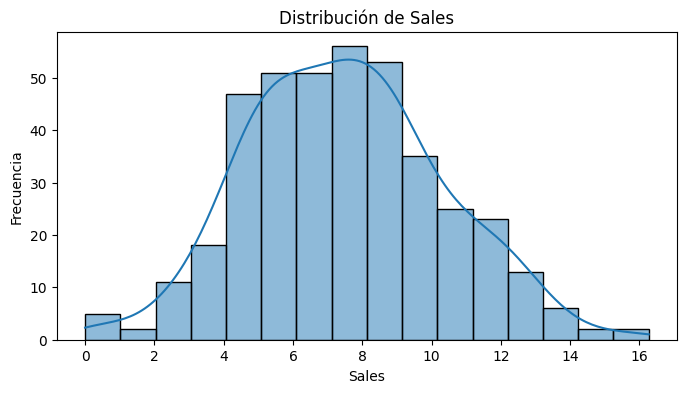


Boxplot de Sales:


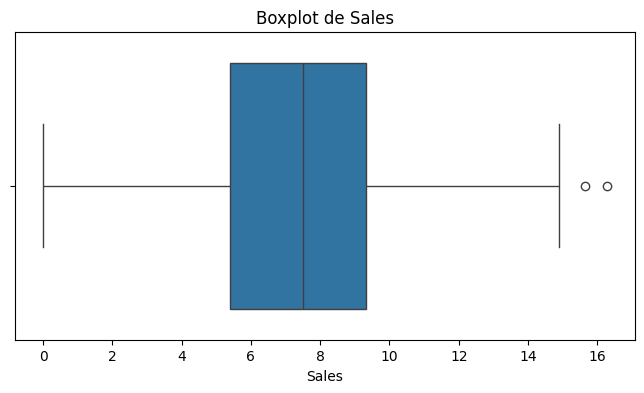

In [97]:
print("Distribución de Sales:")
plt.figure(figsize=(8, 4))
sns.histplot(df_clp["Sales"], kde=True)
plt.title("Distribución de Sales")
plt.xlabel("Sales")
plt.ylabel("Frecuencia")
plt.show()

print("\nBoxplot de Sales:")
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clp["Sales"])
plt.title("Boxplot de Sales")
plt.xlabel("Sales")
plt.show()

### Interpretación de Sales

La distribución de `Sales` muestra una concentración importante de valores en torno al rango medio de ventas, aproximadamente entre 5 y 10. La forma general es bastante cercana a una distribución normal, aunque se observan algunos valores más altos hacia el extremo derecho. El boxplot muestra que la mayoría de los datos se mantiene dentro de un rango estable, pero existen algunos valores atípicos superiores, correspondientes a tiendas con ventas considerablemente más altas que el resto.

---
### Distribución y Boxplot de CompPrice (CLP)


Distribución de CompPrice (CLP):


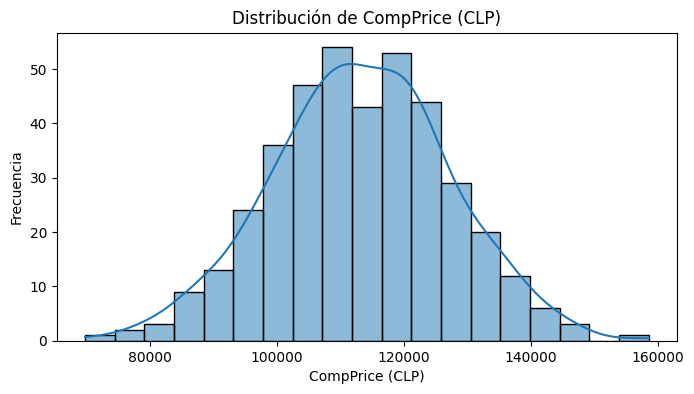


Boxplot de CompPrice (CLP):


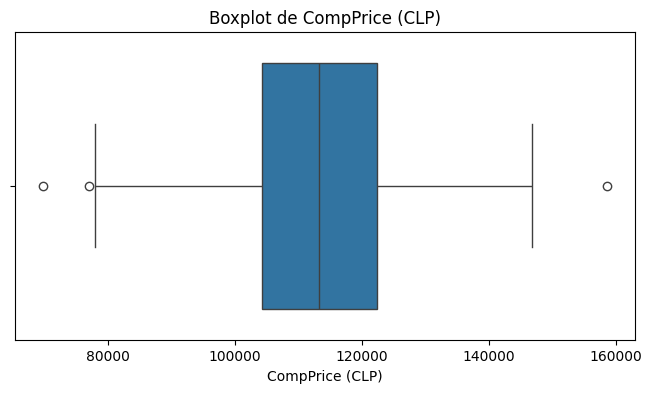

In [98]:
print("\nDistribución de CompPrice (CLP):")
plt.figure(figsize=(8, 4))
sns.histplot(df_clp["CompPrice"], kde=True)
plt.title("Distribución de CompPrice (CLP)")
plt.xlabel("CompPrice (CLP)")
plt.ylabel("Frecuencia")
plt.show()

print("\nBoxplot de CompPrice (CLP):")
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clp["CompPrice"])
plt.title("Boxplot de CompPrice (CLP)")
plt.xlabel("CompPrice (CLP)")
plt.show()

### Interpretación de CompPrice (CLP)

La distribución de `CompPrice` presenta una forma aproximadamente normal, con la mayoría de los precios de la competencia concentrados alrededor del rango central. El boxplot muestra algunos valores atípicos en los extremos, lo que indica que existen competidores con precios más bajos o más altos que la mayoría. En general, la variable mantiene una distribución bastante equilibrada.

---
### Distribución y Boxplot de Income (CLP)


Distribución de Income (CLP):


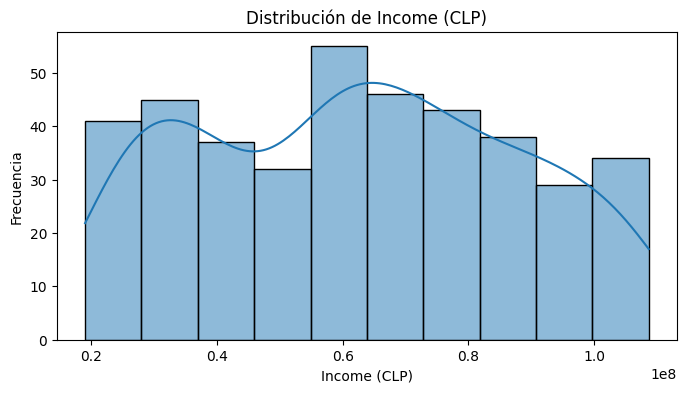


Boxplot de Income (CLP):


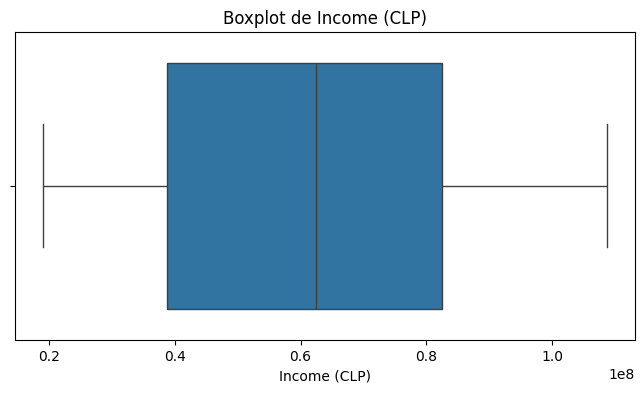

In [99]:
print("\nDistribución de Income (CLP):")
plt.figure(figsize=(8, 4))
sns.histplot(df_clp["Income"], kde=True)
plt.title("Distribución de Income (CLP)")
plt.xlabel("Income (CLP)")
plt.ylabel("Frecuencia")
plt.show()

print("\nBoxplot de Income (CLP):")
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clp["Income"])
plt.title("Boxplot de Income (CLP)")
plt.xlabel("Income (CLP)")
plt.show()

### Interpretación de Income (CLP)

La variable `Income` presenta una distribución amplia, con valores repartidos en distintos rangos de ingreso. No se observan valores atípicos importantes en el boxplot, lo que indica que los datos se mantienen dentro de un rango esperado. La dispersión de esta variable es considerable, por lo que podría ser interesante analizar más adelante si el nivel de ingreso tiene alguna relación con las ventas.

---
### Distribución y Boxplot de Advertising (CLP)


Distribución de Advertising (CLP):


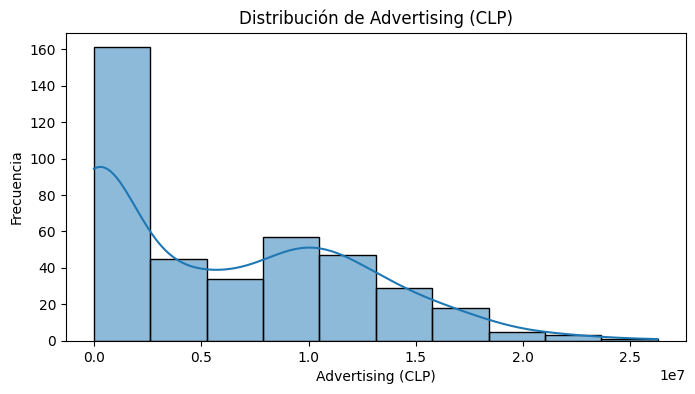


Boxplot de Advertising (CLP):


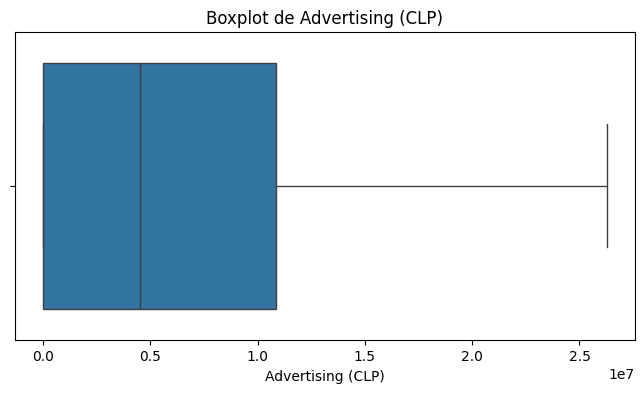

In [100]:
print("\nDistribución de Advertising (CLP):")
plt.figure(figsize=(8, 4))
sns.histplot(df_clp["Advertising"], kde=True)
plt.title("Distribución de Advertising (CLP)")
plt.xlabel("Advertising (CLP)")
plt.ylabel("Frecuencia")
plt.show()

print("\nBoxplot de Advertising (CLP):")
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clp["Advertising"])
plt.title("Boxplot de Advertising (CLP)")
plt.xlabel("Advertising (CLP)")
plt.show()

### Interpretación de Advertising (CLP)

La distribución de `Advertising` muestra una alta concentración de tiendas con poca o ninguna inversión en publicidad. También se observa una cola hacia la derecha, lo que indica que existen tiendas con inversiones publicitarias más altas, aunque son menos frecuentes. El boxplot refleja esta concentración en valores bajos, pero no muestra valores atípicos extremos de forma tan marcada. Esto sugiere que la publicidad tiene una distribución asimétrica y será importante analizar posteriormente su relación con `Sales`.

---
### Distribución y Boxplot de Population


Distribución de Population:


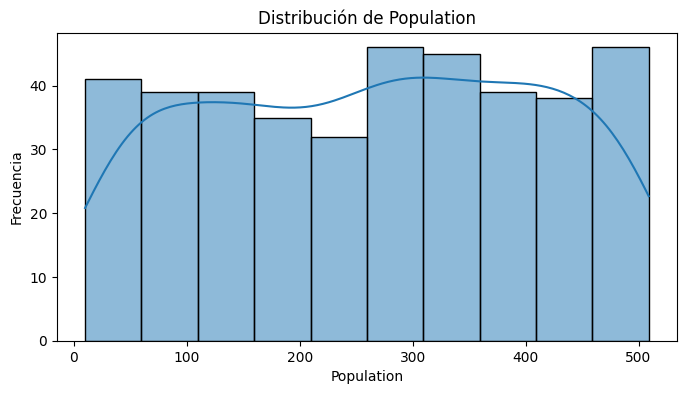


Boxplot de Population:


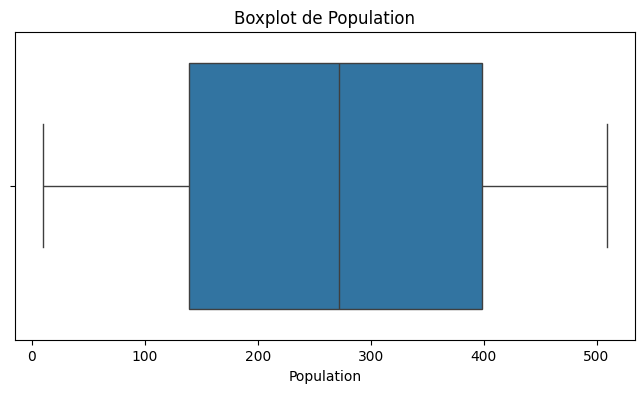

In [101]:
print("\nDistribución de Population:")
plt.figure(figsize=(8, 4))
sns.histplot(df_clp["Population"], kde=True)
plt.title("Distribución de Population")
plt.xlabel("Population")
plt.ylabel("Frecuencia")
plt.show()

print("\nBoxplot de Population:")
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clp["Population"])
plt.title("Boxplot de Population")
plt.xlabel("Population")
plt.show()

### Interpretación de Population

La variable `Population` muestra una distribución relativamente repartida a lo largo de su rango, sin una concentración excesiva en un único valor. El boxplot no evidencia valores atípicos relevantes, por lo que no se observan poblaciones extremadamente alejadas del comportamiento general. Esta variable podría ser útil para revisar si el tamaño de la población se relaciona con las ventas, aunque por sí sola no permite concluirlo.

---
### Distribución y Boxplot de Price (CLP)


Distribución de Price (CLP):


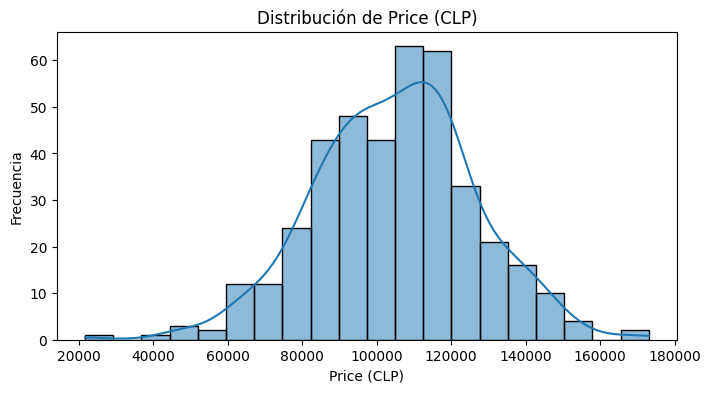


Boxplot de Price (CLP):


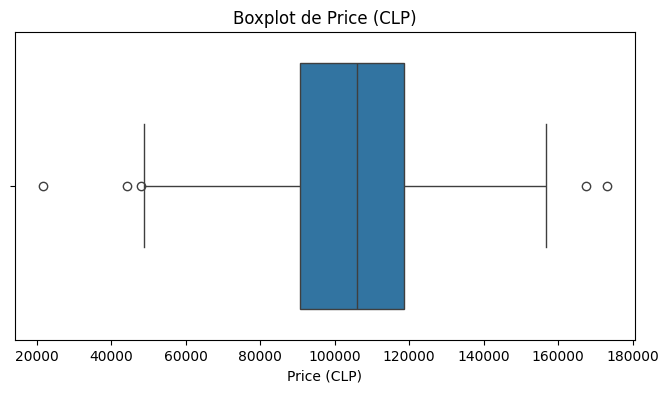

In [102]:
print("\nDistribución de Price (CLP):")
plt.figure(figsize=(8, 4))
sns.histplot(df_clp["Price"], kde=True)
plt.title("Distribución de Price (CLP)")
plt.xlabel("Price (CLP)")
plt.ylabel("Frecuencia")
plt.show()

print("\nBoxplot de Price (CLP):")
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clp["Price"])
plt.title("Boxplot de Price (CLP)")
plt.xlabel("Price (CLP)")
plt.show()

### Interpretación de Price (CLP)

La distribución de `Price` se concentra principalmente en valores medios, especialmente alrededor del rango central de precios. El boxplot muestra la presencia de algunos valores atípicos tanto en precios bajos como en precios altos, lo que indica que existen productos con precios bastante distintos al comportamiento general. Debido a que el precio suele influir en la decisión de compra, esta variable será importante al analizar su relación con `Sales`.

---
### Distribución y Boxplot de Age


Distribución de Age:


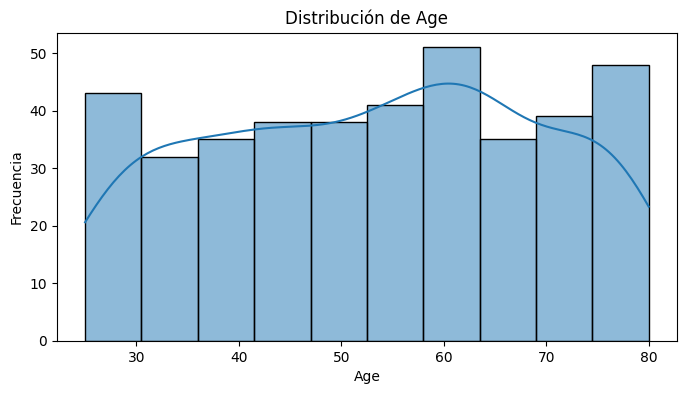


Boxplot de Age:


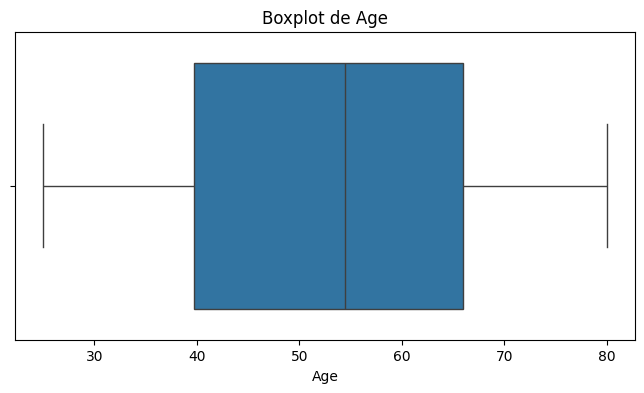

In [103]:
print("\nDistribución de Age:")
plt.figure(figsize=(8, 4))
sns.histplot(df_clp["Age"], kde=True)
plt.title("Distribución de Age")
plt.xlabel("Age")
plt.ylabel("Frecuencia")
plt.show()

print("\nBoxplot de Age:")
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clp["Age"])
plt.title("Boxplot de Age")
plt.xlabel("Age")
plt.show()

### Interpretación de Age

La variable `Age` muestra una distribución bastante repartida dentro de su rango, sin una concentración extrema en un grupo específico. El boxplot no muestra valores atípicos importantes, por lo que las edades se mantienen dentro de un rango esperado. Más adelante será útil revisar si esta variable presenta alguna relación con las ventas, especialmente porque podría representar diferencias en las características de la población asociada a cada tienda.

---
### Frecuencia y Boxplot de Education


Frecuencia de Education:


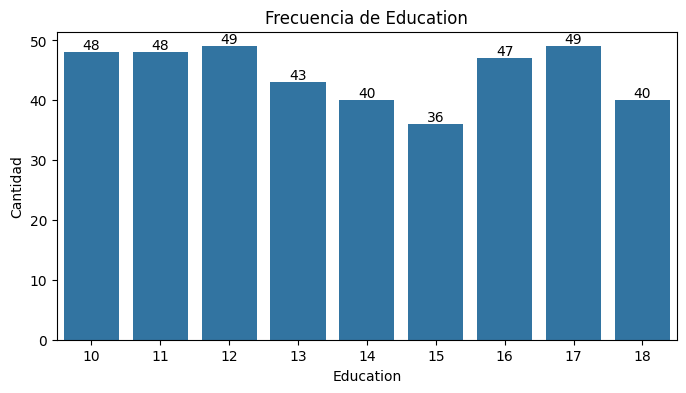


Boxplot de Education:


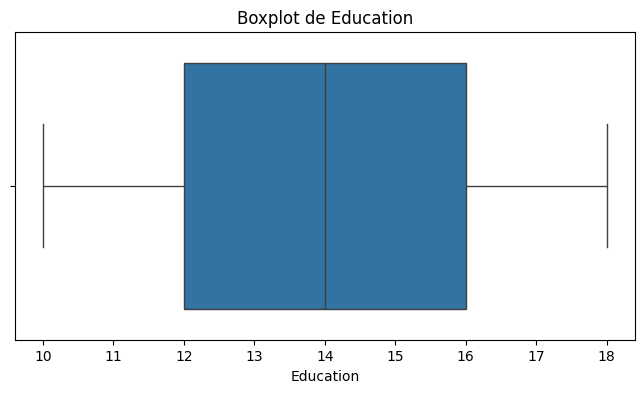

In [104]:
print("\nFrecuencia de Education:")
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_clp, x="Education")
plt.title("Frecuencia de Education")
plt.xlabel("Education")
plt.ylabel("Cantidad")
ax.bar_label(ax.containers[0])
plt.show()

print("\nBoxplot de Education:")
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clp["Education"])
plt.title("Boxplot de Education")
plt.xlabel("Education")
plt.show()

### Interpretación de Education

La variable `Education` representa los años de educación. El gráfico de frecuencia muestra que los valores se encuentran entre 10 y 18 años, con cantidades relativamente similares entre las distintas categorías. El boxplot no muestra valores atípicos relevantes, lo que indica que los niveles educativos están dentro de un rango esperado. Al tratarse de una variable discreta, el countplot resulta más adecuado que un histograma con curva KDE.

---
### Frecuencia y porcentaje de ShelveLoc


Frecuencia de ShelveLoc:


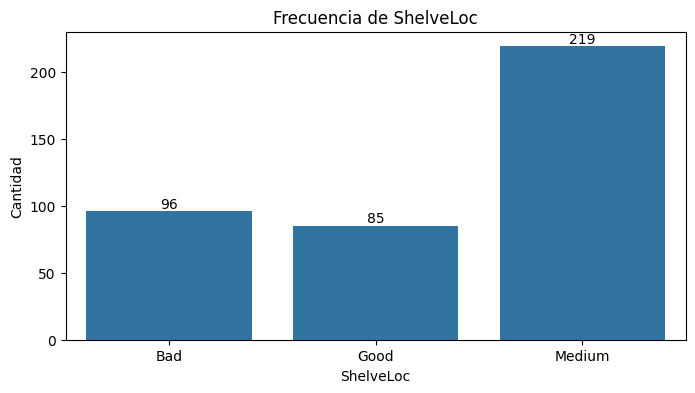

In [105]:
print("\nFrecuencia de ShelveLoc:")
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_clp, x="ShelveLoc")
plt.title("Frecuencia de ShelveLoc")
plt.xlabel("ShelveLoc")
plt.ylabel("Cantidad")
ax.bar_label(ax.containers[0])
plt.show()


Porcentaje de ShelveLoc:


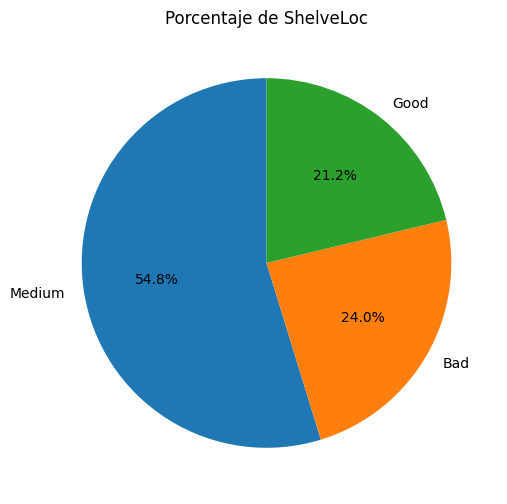

In [106]:
print("\nPorcentaje de ShelveLoc:")
plt.figure(figsize=(6, 6))
df_clp["ShelveLoc"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Porcentaje de ShelveLoc")
plt.ylabel("")
plt.show()

### Interpretación de ShelveLoc

La variable `ShelveLoc` muestra que la mayoría de los productos se encuentran en una ubicación de estantería `Medium`, seguida por `Bad` y luego `Good`. Esto indica que las ubicaciones buenas son menos frecuentes en el dataset. Dado que la ubicación en estantería puede afectar la visibilidad del producto, será importante analizar posteriormente si las tiendas con mejor ubicación presentan mayores ventas.

---
### Frecuencia y porcentaje de Urban


Frecuencia de Urban:


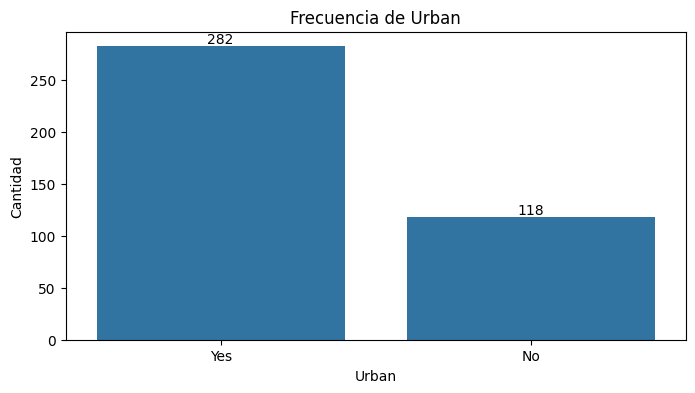

In [107]:
print("\nFrecuencia de Urban:")
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_clp, x="Urban")
plt.title("Frecuencia de Urban")
plt.xlabel("Urban")
plt.ylabel("Cantidad")
ax.bar_label(ax.containers[0])
plt.show()


Porcentaje de Urban:


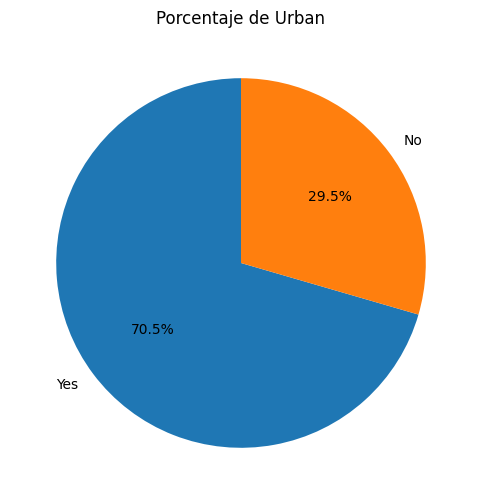

In [108]:
print("\nPorcentaje de Urban:")
plt.figure(figsize=(6, 6))
df_clp["Urban"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Porcentaje de Urban")
plt.ylabel("")
plt.show()

### Interpretación de Urban

La variable `Urban` muestra que la mayoría de las tiendas se encuentran en zonas urbanas, mientras que una menor proporción corresponde a zonas no urbanas. Esta diferencia indica que el dataset está más representado por tiendas urbanas. Sin embargo, con este gráfico solo se observa la distribución de la variable, por lo que todavía no se puede concluir si estar en una zona urbana influye o no en las ventas.

---
### Frecuencia y porcentaje de US


Frecuencia de US:


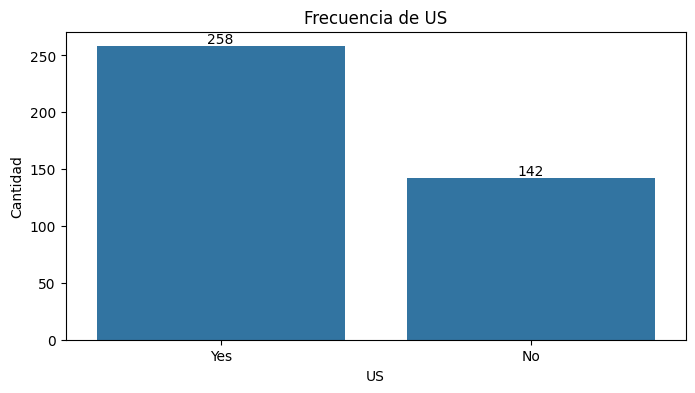

In [109]:
print("\nFrecuencia de US:")
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_clp, x="US")
plt.title("Frecuencia de US")
plt.xlabel("US")
plt.ylabel("Cantidad")
ax.bar_label(ax.containers[0])
plt.show()


Porcentaje de US:


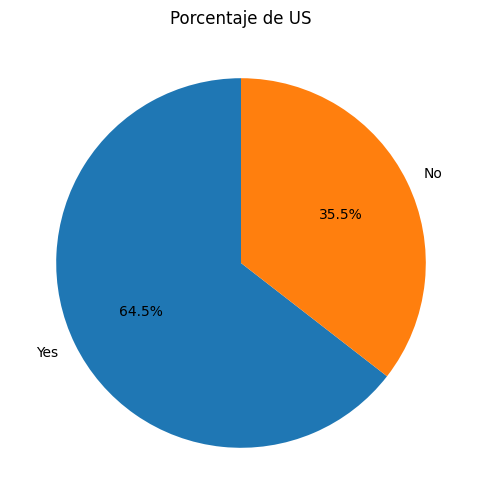

In [110]:
print("\nPorcentaje de US:")
plt.figure(figsize=(6, 6))
df_clp["US"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Porcentaje de US")
plt.ylabel("")
plt.show()

### Interpretación de US

La variable `US` muestra que la mayoría de las tiendas del dataset se encuentran en Estados Unidos, mientras que una proporción menor corresponde a tiendas fuera de Estados Unidos. Esta variable puede ser relevante para comparar diferencias de mercado, pero con el gráfico de frecuencia y porcentaje solo se observa la composición del dataset. Para evaluar su impacto real, es necesario analizar su relación con `Sales`.

### Relaciones entre variables

En esta parte se analizan relaciones entre `Sales` y las variables numéricas y categóricas más relevantes.


Mapa de calor de correlaciones:


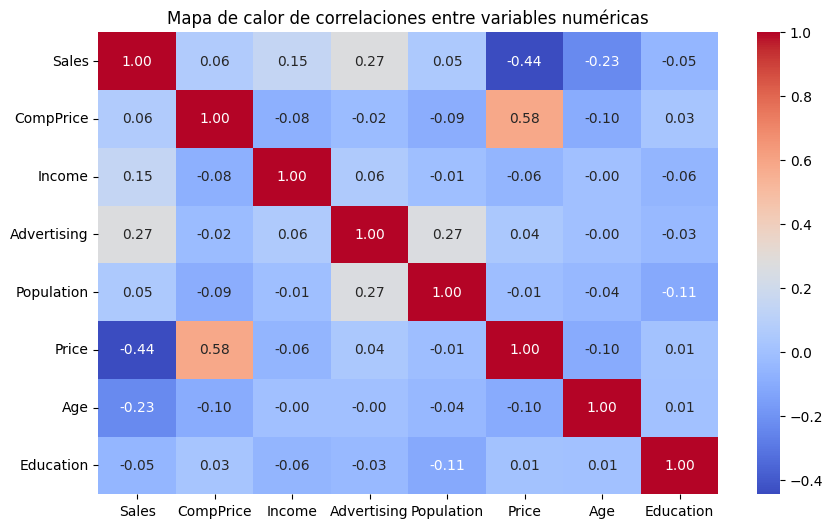

In [112]:
print("\nMapa de calor de correlaciones:")

plt.figure(figsize=(10, 6))
correlacion = df_clp.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de calor de correlaciones entre variables numéricas")
plt.show()

### Interpretación del Mapa de Calor de Correlaciones

El mapa de calor muestra que `Price` es la variable numérica con relación negativa más clara respecto a `Sales`, lo que sugiere que a mayor precio, las ventas tienden a disminuir. `Advertising` presenta una correlación positiva débil a moderada con `Sales`, indicando que una mayor inversión publicitaria podría asociarse con mayores ventas. `Age` muestra una relación negativa débil, mientras que variables como `Population`, `Education` y `CompPrice` presentan relaciones lineales más bajas con las ventas. También se observa una correlación positiva moderada entre `CompPrice` y `Price`, lo cual es esperable al tratarse de variables relacionadas con precios.


Relación entre Price (CLP) y Sales:


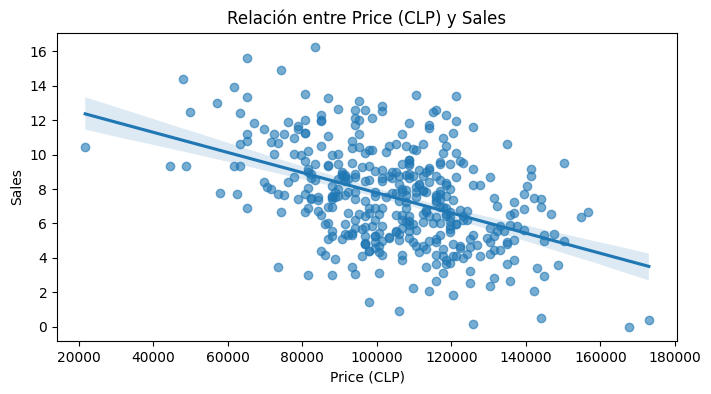

In [113]:
print("\nRelación entre Price (CLP) y Sales:")

plt.figure(figsize=(8, 4))
sns.regplot(data=df_clp, x="Price", y="Sales", scatter_kws={"alpha": 0.6})
plt.title("Relación entre Price (CLP) y Sales")
plt.xlabel("Price (CLP)")
plt.ylabel("Sales")
plt.show()

### Interpretación de la Relación entre Price (CLP) y Sales

El gráfico de dispersión con línea de tendencia muestra una relación negativa entre `Price` y `Sales`. A medida que el precio aumenta, las ventas tienden a disminuir. Sin embargo, los puntos presentan bastante dispersión, por lo que el precio no explica por sí solo todo el comportamiento de las ventas. Esto indica que existen otros factores que también pueden influir en el rendimiento comercial.


Relación entre Advertising (CLP) y Sales:


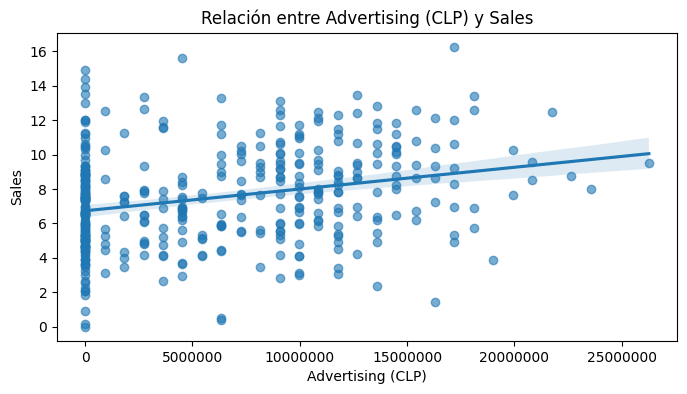

In [114]:
print("\nRelación entre Advertising (CLP) y Sales:")

plt.figure(figsize=(8, 4))
sns.regplot(data=df_clp, x="Advertising", y="Sales", scatter_kws={"alpha": 0.6})
plt.title("Relación entre Advertising (CLP) y Sales")
plt.xlabel("Advertising (CLP)")
plt.ylabel("Sales")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))
plt.show()

### Interpretación de la Relación entre Advertising (CLP) y Sales

El gráfico muestra una relación positiva débil entre `Advertising` y `Sales`. Se observa que muchas tiendas tienen inversión publicitaria igual a 0 CLP, pero aun así presentan ventas, por lo que no debe interpretarse como ventas de 0. La línea de tendencia indica que una mayor inversión en publicidad podría asociarse con ventas ligeramente mayores, aunque la dispersión de los puntos muestra que la publicidad no es el único factor que influye en las ventas.


Relación entre Income (CLP) y Sales:


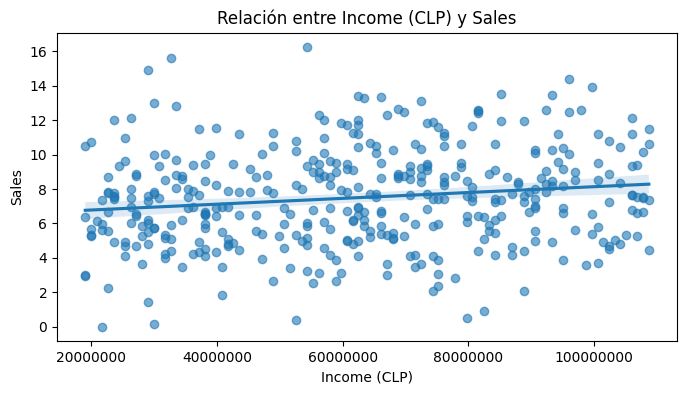

In [115]:
print("\nRelación entre Income (CLP) y Sales:")

plt.figure(figsize=(8, 4))
sns.regplot(data=df_clp, x="Income", y="Sales", scatter_kws={"alpha": 0.6})
plt.title("Relación entre Income (CLP) y Sales")
plt.xlabel("Income (CLP)")
plt.ylabel("Sales")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))
plt.show()

### Interpretación de la Relación entre Income (CLP) y Sales

La relación entre `Income` y `Sales` parece ser débil. Aunque la línea de tendencia muestra una leve inclinación positiva, los puntos están bastante dispersos. Esto indica que el ingreso de la zona no presenta una relación lineal fuerte con las ventas. Por lo tanto, esta variable podría aportar información, pero no parece ser uno de los factores más determinantes por sí sola.


Relación entre Age y Sales:


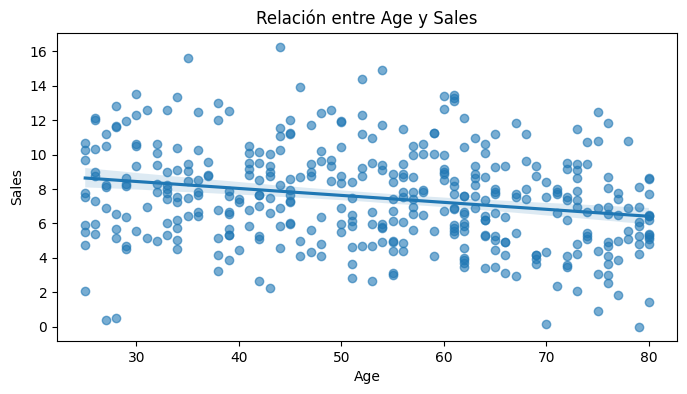

In [116]:
print("\nRelación entre Age y Sales:")

plt.figure(figsize=(8, 4))
sns.regplot(data=df_clp, x="Age", y="Sales", scatter_kws={"alpha": 0.6})
plt.title("Relación entre Age y Sales")
plt.xlabel("Age")
plt.ylabel("Sales")
plt.show()

### Interpretación de la Relación entre Age y Sales

El gráfico muestra una relación negativa débil entre `Age` y `Sales`. La línea de tendencia sugiere que, a medida que aumenta la edad promedio, las ventas tienden a disminuir ligeramente. Sin embargo, la dispersión de los puntos es alta, por lo que esta relación no es fuerte. Esta variable podría considerarse en el análisis, pero no permite explicar las ventas de forma individual.


Relación entre Population y Sales:


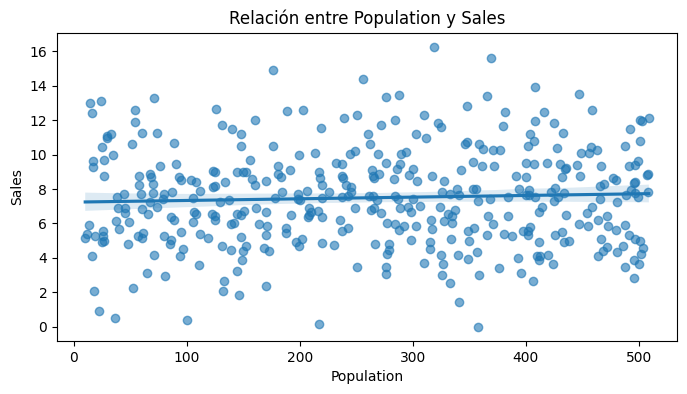

In [117]:
print("\nRelación entre Population y Sales:")

plt.figure(figsize=(8, 4))
sns.regplot(data=df_clp, x="Population", y="Sales", scatter_kws={"alpha": 0.6})
plt.title("Relación entre Population y Sales")
plt.xlabel("Population")
plt.ylabel("Sales")
plt.show()

### Interpretación de la Relación entre Population y Sales

La relación entre `Population` y `Sales` es muy débil. La línea de tendencia se mantiene casi horizontal y los puntos aparecen bastante dispersos. Esto sugiere que el tamaño de la población no presenta una relación lineal clara con las ventas. Por lo tanto, según este gráfico, `Population` no parece ser una variable altamente explicativa por sí sola.


Sales según Education:


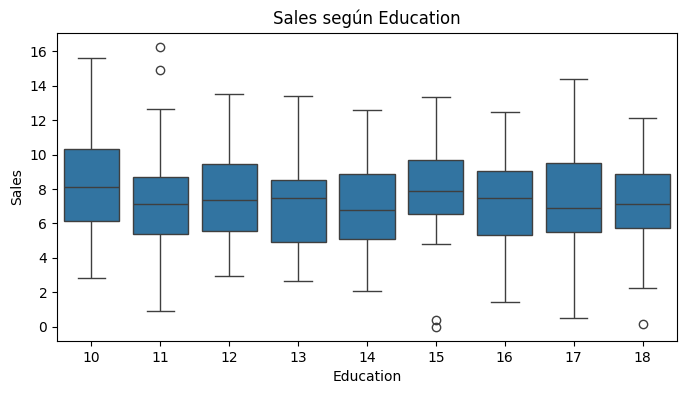

In [118]:
print("\nSales según Education:")

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clp, x="Education", y="Sales")
plt.title("Sales según Education")
plt.xlabel("Education")
plt.ylabel("Sales")
plt.show()

### Interpretación de Sales según Education

El boxplot de `Sales` según `Education` muestra que las medianas de ventas son relativamente similares entre los distintos niveles educativos. Aunque existen algunas diferencias en la dispersión y algunos valores atípicos, no se observa una tendencia clara que indique que un mayor o menor nivel educativo esté asociado directamente con ventas más altas. Por lo tanto, esta variable no parece tener una relación fuerte con `Sales` a simple vista.


Distribución de Sales según ShelveLoc:


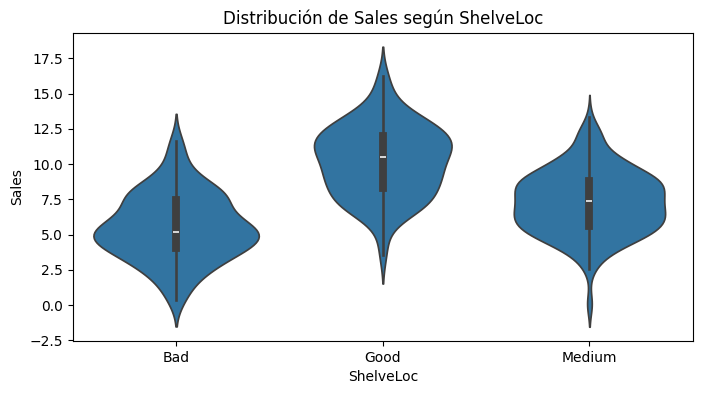

In [119]:
print("\nDistribución de Sales según ShelveLoc:")

plt.figure(figsize=(8, 4))
sns.violinplot(data=df_clp, x="ShelveLoc", y="Sales")
plt.title("Distribución de Sales según ShelveLoc")
plt.xlabel("ShelveLoc")
plt.ylabel("Sales")
plt.show()


Boxplot de Sales según ShelveLoc:


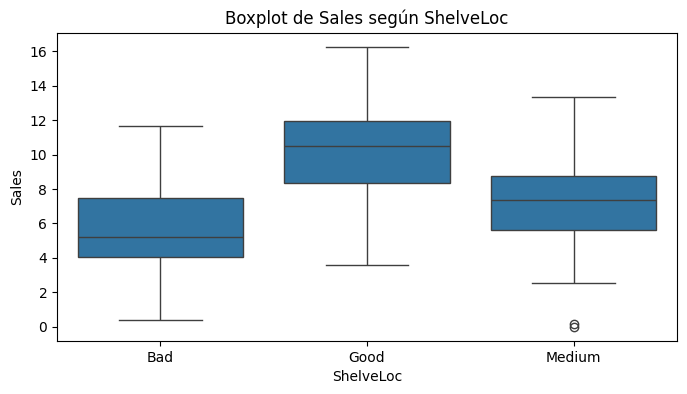

In [120]:
print("\nBoxplot de Sales según ShelveLoc:")

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clp, x="ShelveLoc", y="Sales")
plt.title("Boxplot de Sales según ShelveLoc")
plt.xlabel("ShelveLoc")
plt.ylabel("Sales")
plt.show()

### Interpretación de Sales según ShelveLoc

Los gráficos de violín y boxplot muestran una diferencia clara en las ventas según `ShelveLoc`. Las tiendas con ubicación `Good` presentan una mediana de ventas más alta que las categorías `Medium` y `Bad`. En cambio, `Bad` tiende a concentrarse en valores de ventas más bajos. Esto sugiere que una mejor ubicación en estantería se asocia con mayores ventas, por lo que `ShelveLoc` parece ser una de las variables categóricas más relevantes del análisis.


Sales según Urban:


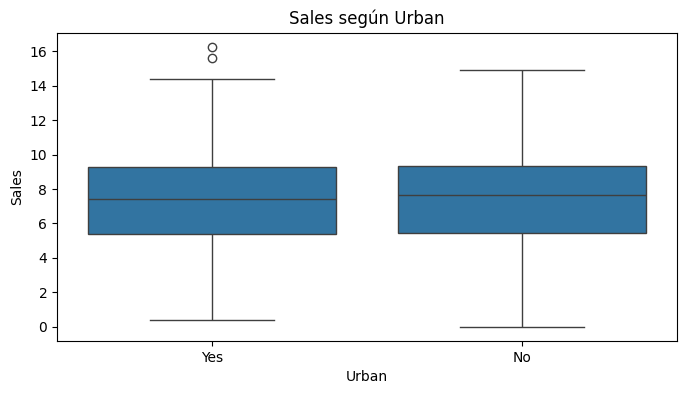

In [121]:
print("\nSales según Urban:")

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clp, x="Urban", y="Sales")
plt.title("Sales según Urban")
plt.xlabel("Urban")
plt.ylabel("Sales")
plt.show()

### Interpretación de Sales según Urban

El boxplot de `Sales` según `Urban` muestra que las medianas de ventas entre tiendas urbanas y no urbanas son bastante similares. La dispersión también es comparable entre ambas categorías. Esto sugiere que, a simple vista, estar en una zona urbana o no urbana no genera una diferencia marcada en las ventas.


Sales según US:


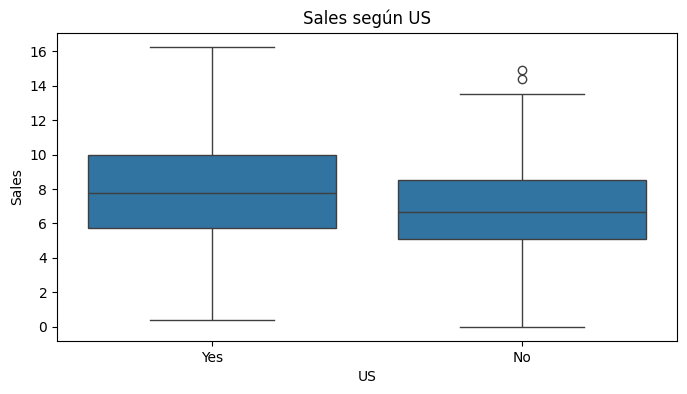

In [122]:
print("\nSales según US:")

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clp, x="US", y="Sales")
plt.title("Sales según US")
plt.xlabel("US")
plt.ylabel("Sales")
plt.show()

### Interpretación de Sales según US

El boxplot de `Sales` según `US` muestra que las tiendas ubicadas en Estados Unidos presentan una mediana de ventas levemente superior a las tiendas fuera de Estados Unidos. Sin embargo, existe una superposición importante entre ambas distribuciones, por lo que la diferencia no parece ser muy fuerte. Esto indica que la variable `US` podría tener cierta asociación con las ventas, pero no parece ser determinante por sí sola.

### Interpretación general de las relaciones

En esta sección se analizaron las relaciones entre `Sales` y las demás variables del dataset. En las variables numéricas, `Price` destaca como la relación negativa más clara con las ventas, lo que sugiere que un aumento en el precio podría asociarse con menores ventas. `Advertising` presenta una relación positiva, aunque no demasiado fuerte, mientras que `Income`, `Age`, `Population` y `Education` muestran relaciones más débiles.

En las variables categóricas, `ShelveLoc` muestra la diferencia más evidente, ya que las tiendas con ubicación `Good` presentan mayores niveles de ventas. En cambio, `Urban` no muestra diferencias importantes, y `US` presenta una diferencia leve a favor de las tiendas ubicadas en Estados Unidos.

En general, las variables que parecen más relevantes para explicar el comportamiento de `Sales` son `Price`, `Advertising` y `ShelveLoc`. Estas variables deberían considerarse con mayor atención en las siguientes etapas del proyecto, aunque las conclusiones definitivas deben basarse en la evaluación de los modelos.

## 8. Módulo 4: Preprocesamiento para modelamiento

En este módulo se prepara la información para entrenar modelos predictivos.

Es importante diferenciar el **Pipeline Híbrido Modular** utilizado como arquitectura general del proyecto, del objeto `Pipeline` de Scikit-Learn. El primero organiza todo el flujo del proyecto desde la ingesta de datos hasta el dashboard final, mientras que el segundo se utiliza dentro del módulo de modelamiento para automatizar el preprocesamiento y entrenamiento de modelos.

De esta forma, el pipeline técnico de machine learning forma parte del pipeline general del proyecto.

In [123]:
# Separación de variables predictoras y variable objetivo

X = df_clp.drop(columns=["Sales"])
y = df_clp["Sales"]

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (400, 10)
Variable objetivo: (400,)


In [124]:
# División entre datos de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (320, 10)
Tamaño de prueba: (80, 10)


In [125]:
# Identificación de columnas numéricas y categóricas para el pipeline técnico

columnas_numericas_modelo = X_train.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas_modelo = X_train.select_dtypes(include=["object", "category"]).columns

print("Columnas numéricas:")
print(columnas_numericas_modelo)

print("\nColumnas categóricas:")
print(columnas_categoricas_modelo)

Columnas numéricas:
Index(['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age',
       'Education'],
      dtype='object')

Columnas categóricas:
Index(['ShelveLoc', 'Urban', 'US'], dtype='object')


In [138]:
# Pipeline para variables numéricas
pipeline_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler())
])

# Pipeline para variables categóricas
pipeline_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore"))
])

# Unión de ambos procesos en un ColumnTransformer
preprocesamiento = ColumnTransformer(transformers=[
    ("numericas", pipeline_numerico, columnas_numericas_modelo),
    ("categoricas", pipeline_categorico, columnas_categoricas_modelo)
])


## 9. Módulo 5: Modelamiento predictivo

En este módulo se implementa el algoritmo predictivo seleccionado para el proyecto: **Random Forest Regressor**.

La elección del modelo se realiza a partir de las características del problema y no mediante una prueba masiva de algoritmos. El objetivo es predecir `Sales`, por lo que corresponde a un problema de **regresión** sobre datos tabulares. Además, el dataset contiene variables numéricas y categóricas, y es razonable esperar que las ventas dependan de combinaciones entre variables como precio, publicidad, competencia y ubicación del producto.

Se consideraron alternativas como Regresión Lineal, Árbol de Decisión y modelos más complejos. Sin embargo, se selecciona **Random Forest Regressor** porque ofrece un equilibrio adecuado entre capacidad predictiva, estabilidad y complejidad moderada. A diferencia de una regresión lineal, puede capturar relaciones no lineales; y a diferencia de un solo árbol de decisión, reduce la inestabilidad al trabajar con múltiples árboles.

Por esta razón, en el código se implementa únicamente el modelo seleccionado.


In [139]:
# Definición del modelo seleccionado dentro de un pipeline completo

modelo_random_forest = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("modelo", RandomForestRegressor(random_state=42, n_estimators=200))
])


In [128]:
# Entrenamiento del modelo seleccionado

modelo_random_forest.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")


Modelo Random Forest entrenado correctamente.


In [129]:
# Predicciones sobre el conjunto de prueba

pred_random_forest = modelo_random_forest.predict(X_test)

print("Predicciones generadas correctamente.")


Predicciones generadas correctamente.


## 10. Módulo 6: Evaluación del modelo

En este módulo se evalúa el desempeño del modelo seleccionado usando métricas de regresión:

- **MAE:** error absoluto medio. Mientras menor sea, mejor.
- **RMSE:** raíz del error cuadrático medio. Penaliza más los errores grandes. Mientras menor sea, mejor.
- **R²:** proporción de variabilidad explicada por el modelo. Mientras más cercano a 1, mejor.

Estas métricas permiten analizar si el modelo seleccionado entrega predicciones razonables sobre datos que no fueron usados durante el entrenamiento.


In [130]:
# Evaluación del modelo Random Forest

mae_rf = mean_absolute_error(y_test, pred_random_forest)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_random_forest))
r2_rf = r2_score(y_test, pred_random_forest)

resultados_modelo = pd.DataFrame([{
    "Modelo": "Random Forest Regressor",
    "MAE": mae_rf,
    "RMSE": rmse_rf,
    "R²": r2_rf
}])

display(resultados_modelo)


,Modelo,MAE,RMSE,R²
0,Random Forest Regressor,1.415904,1.73627,0.695375


In [131]:
# Interpretación automática de los resultados del modelo

display(Markdown(f"""### Resultado de la evaluación

El modelo implementado fue **Random Forest Regressor**.

- **MAE:** {mae_rf:.3f}
- **RMSE:** {rmse_rf:.3f}
- **R²:** {r2_rf:.3f}

El RMSE se utiliza como una métrica importante porque permite medir el error del modelo penalizando con mayor fuerza las predicciones más alejadas del valor real. El R² permite observar qué proporción de la variabilidad de `Sales` logra explicar el modelo.
"""))


### Resultado de la evaluación

El modelo implementado fue **Random Forest Regressor**.

- **MAE:** 1.416
- **RMSE:** 1.736
- **R²:** 0.695

El RMSE se utiliza como una métrica importante porque permite medir el error del modelo penalizando con mayor fuerza las predicciones más alejadas del valor real. El R² permite observar qué proporción de la variabilidad de `Sales` logra explicar el modelo.


### Importancia de variables del modelo seleccionado

Como el modelo implementado es Random Forest, se revisa la importancia de variables para apoyar la interpretación del problema. Esto permite observar qué variables tienen mayor participación en las predicciones del modelo.


,Variable,Importancia
4,numericas__Price,0.309450
8,categoricas__ShelveLoc_Good,0.170422
5,numericas__Age,0.116624
0,numericas__CompPrice,0.093387
2,numericas__Advertising,0.084944
7,categoricas__ShelveLoc_Bad,0.060251
1,numericas__Income,0.051310
3,numericas__Population,0.038634
9,categoricas__ShelveLoc_Medium,0.031890
6,numericas__Education,0.029099


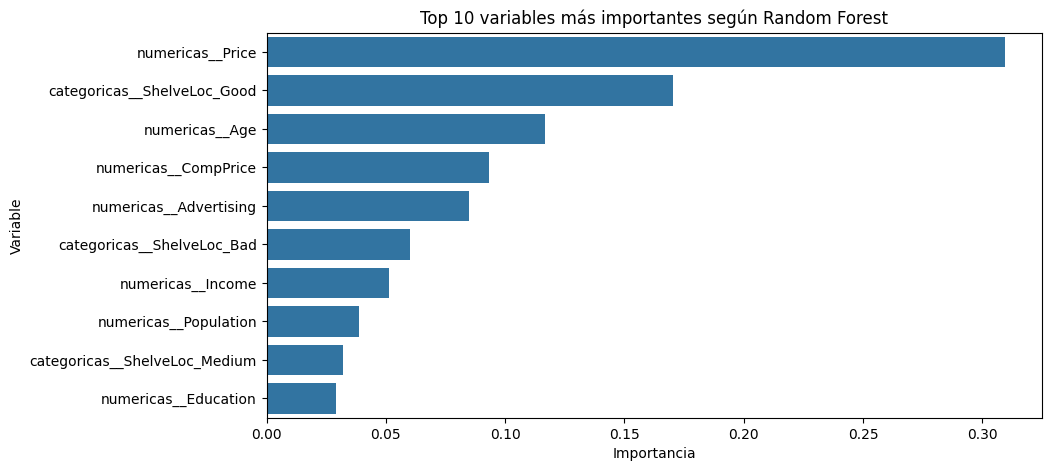

In [132]:
# Importancia de variables usando Random Forest

nombres_variables_transformadas = modelo_random_forest.named_steps["preprocesamiento"].get_feature_names_out()
importancias = modelo_random_forest.named_steps["modelo"].feature_importances_

importancia_variables = pd.DataFrame({
    "Variable": nombres_variables_transformadas,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

display(importancia_variables.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=importancia_variables.head(10),
    x="Importancia",
    y="Variable"
)
plt.title("Top 10 variables más importantes según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## 11. Módulo 7: Visualización mediante dashboard

En este módulo se implementa un dashboard con Dash para presentar indicadores generales, gráficos exploratorios interactivos y resultados del modelo predictivo seleccionado.

Para aplicar la diferenciación por audiencia solicitada en la rúbrica, el dashboard no organiza los gráficos como una lista general, sino según el tipo de usuario que revisará la información. De esta forma, el filtro principal permite seleccionar una audiencia y mostrar únicamente los gráficos más relevantes para ese perfil.

El dashboard representa la etapa final del Pipeline Híbrido Modular, donde los datos procesados y los resultados del modelo se transforman en información visual para apoyar la toma de decisiones.


### Diferenciación por audiencia aplicada al dashboard

La visualización de resultados no está dirigida a un solo tipo de usuario. Por eso, el dashboard se organiza en tres audiencias principales:

| Audiencia | Qué necesita observar | Gráficos mostrados en el dashboard |
|---|---|---|
| **Ejecutiva o de negocio** | Una visión general del comportamiento de las ventas y de factores comerciales que pueden afectar los resultados. | Distribución de `Sales`, relación entre `Price` y `Sales`, relación entre `Advertising` y `Sales`. |
| **Operativa o de tienda** | Variables accionables dentro del punto de venta, como la ubicación del producto y las características del mercado. | `Sales` según `ShelveLoc`, `Sales` según `Urban`, `Sales` según `US`. |
| **Técnica o de ciencia de datos** | Desempeño del modelo predictivo y variables más relevantes para la predicción. | Importancia de variables, valores reales vs predichos y métricas del modelo. |

Esta organización permite que el dashboard sea más claro, ya que cada audiencia visualiza solo la información que necesita para interpretar los resultados y apoyar la toma de decisiones.


In [133]:
# Preparación de gráficos interactivos para el dashboard
# Se reutilizan gráficos exploratorios principales usando Plotly Express.
# El filtro del dashboard estará organizado por audiencia.

fig_distribucion_sales = px.histogram(
    df_clp,
    x="Sales",
    nbins=25,
    title="Distribución de las ventas",
    color_discrete_sequence=[colores_dashboard[0]]
)

fig_distribucion_sales.update_traces(
    marker={"line": {"color": "#333", "width": 1}},
    hovertemplate="Sales: %{x}<br>Frecuencia: %{y}<extra></extra>"
)

fig_distribucion_sales.update_layout(
    template="plotly_white",
    xaxis_title="Sales",
    yaxis_title="Frecuencia",
    title={"font": {"size": 22, "family": "Tahoma"}}
)

fig_price_sales = px.scatter(
    df_clp,
    x="Price",
    y="Sales",
    title="Relación entre Price (CLP) y Sales",
    color_discrete_sequence=[colores_dashboard[1]]
)

fig_price_sales.update_traces(
    marker={"size": 8, "line": {"color": "#333", "width": 1}},
    hovertemplate="Price (CLP): %{x}<br>Sales: %{y}<extra></extra>"
)

fig_price_sales.update_layout(
    template="plotly_white",
    xaxis_title="Price (CLP)",
    yaxis_title="Sales",
    title={"font": {"size": 22, "family": "Tahoma"}}
)

fig_advertising_sales = px.scatter(
    df_clp,
    x="Advertising",
    y="Sales",
    title="Relación entre Advertising (CLP) y Sales",
    color_discrete_sequence=[colores_dashboard[4]]
)

fig_advertising_sales.update_traces(
    marker={"size": 8, "line": {"color": "#333", "width": 1}},
    hovertemplate="Advertising (CLP): %{x}<br>Sales: %{y}<extra></extra>"
)

fig_advertising_sales.update_layout(
    template="plotly_white",
    xaxis_title="Advertising (CLP)",
    yaxis_title="Sales",
    title={"font": {"size": 22, "family": "Tahoma"}}
)

fig_shelveloc_sales = px.box(
    df_clp,
    x="ShelveLoc",
    y="Sales",
    color="ShelveLoc",
    title="Sales según ShelveLoc",
    color_discrete_sequence=colores_dashboard
)

fig_shelveloc_sales.update_traces(
    marker={"line": {"color": "#333", "width": 1}},
    hovertemplate="ShelveLoc: %{x}<br>Sales: %{y}<extra></extra>"
)

fig_shelveloc_sales.update_layout(
    template="plotly_white",
    xaxis_title="ShelveLoc",
    yaxis_title="Sales",
    title={"font": {"size": 22, "family": "Tahoma"}},
    showlegend=False
)

fig_urban_sales = px.box(
    df_clp,
    x="Urban",
    y="Sales",
    color="Urban",
    title="Sales según zona urbana",
    color_discrete_sequence=colores_dashboard
)

fig_urban_sales.update_traces(
    marker={"line": {"color": "#333", "width": 1}},
    hovertemplate="Urban: %{x}<br>Sales: %{y}<extra></extra>"
)

fig_urban_sales.update_layout(
    template="plotly_white",
    xaxis_title="Urban",
    yaxis_title="Sales",
    title={"font": {"size": 22, "family": "Tahoma"}},
    showlegend=False
)

fig_us_sales = px.box(
    df_clp,
    x="US",
    y="Sales",
    color="US",
    title="Sales según mercado US",
    color_discrete_sequence=colores_dashboard
)

fig_us_sales.update_traces(
    marker={"line": {"color": "#333", "width": 1}},
    hovertemplate="US: %{x}<br>Sales: %{y}<extra></extra>"
)

fig_us_sales.update_layout(
    template="plotly_white",
    xaxis_title="US",
    yaxis_title="Sales",
    title={"font": {"size": 22, "family": "Tahoma"}},
    showlegend=False
)

# Se ordena de menor a mayor para que el gráfico horizontal se lea mejor.
top_importancia = importancia_variables.head(10).sort_values("Importancia", ascending=True)

fig_importancia_variables = px.bar(
    top_importancia,
    x="Importancia",
    y="Variable",
    orientation="h",
    title="Top 10 variables más importantes según Random Forest",
    color="Variable",
    color_discrete_sequence=colores_dashboard,
    text_auto=".3f"
)

fig_importancia_variables.update_traces(
    marker={"line": {"color": "#333", "width": 1}},
    textfont={"family": "consolas", "size": 13},
    hovertemplate="Variable: %{y}<br>Importancia: %{x}<extra></extra>"
)

fig_importancia_variables.update_layout(
    template="plotly_white",
    xaxis_title="Importancia",
    yaxis_title="Variable",
    title={"font": {"size": 22, "family": "Tahoma"}},
    showlegend=False
)

# Gráfico técnico: comparación entre valores reales y predichos.
resultados_prediccion = pd.DataFrame({
    "Sales real": y_test,
    "Sales predicha": pred_random_forest
})

fig_reales_predichos = px.scatter(
    resultados_prediccion,
    x="Sales real",
    y="Sales predicha",
    title="Comparación entre Sales real y Sales predicha",
    color_discrete_sequence=[colores_dashboard[2]]
)

fig_reales_predichos.update_traces(
    marker={"size": 8, "line": {"color": "#333", "width": 1}},
    hovertemplate="Sales real: %{x}<br>Sales predicha: %{y}<extra></extra>"
)

fig_reales_predichos.update_layout(
    template="plotly_white",
    xaxis_title="Sales real",
    yaxis_title="Sales predicha",
    title={"font": {"size": 22, "family": "Tahoma"}}
)

# Gráfico técnico: métricas del modelo.
metricas_modelo = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Valor": [mae_rf, rmse_rf, r2_rf]
})

fig_metricas_modelo = px.bar(
    metricas_modelo,
    x="Métrica",
    y="Valor",
    title="Métricas de evaluación del modelo",
    color="Métrica",
    color_discrete_sequence=colores_dashboard,
    text_auto=".3f"
)

fig_metricas_modelo.update_traces(
    marker={"line": {"color": "#333", "width": 1}},
    textfont={"family": "consolas", "size": 14},
    hovertemplate="Métrica: %{x}<br>Valor: %{y}<extra></extra>"
)

fig_metricas_modelo.update_layout(
    template="plotly_white",
    xaxis_title="Métrica",
    yaxis_title="Valor",
    title={"font": {"size": 22, "family": "Tahoma"}},
    showlegend=False
)

# Diccionario organizado por audiencia.
# Cada audiencia muestra tres gráficos relevantes para ese tipo de usuario.
graficos_por_audiencia = {
    "negocio": {
        "titulo": "Audiencia ejecutiva o de negocio",
        "descripcion": "Esta vista resume el comportamiento general de las ventas y variables comerciales que pueden influir en los resultados.",
        "graficos": [fig_distribucion_sales, fig_price_sales, fig_advertising_sales]
    },
    "operativa": {
        "titulo": "Audiencia operativa o de tienda",
        "descripcion": "Esta vista se enfoca en variables accionables dentro del punto de venta, como ubicación del producto y características del mercado.",
        "graficos": [fig_shelveloc_sales, fig_urban_sales, fig_us_sales]
    },
    "tecnica": {
        "titulo": "Audiencia técnica o de ciencia de datos",
        "descripcion": "Esta vista permite revisar el desempeño del modelo Random Forest y las variables que más aportan a la predicción.",
        "graficos": [fig_importancia_variables, fig_reales_predichos, fig_metricas_modelo]
    }
}

app = Dash(__name__)

app.layout = html.Div([
    html.H1("Dashboard Proyecto CarSeats"),
    html.H2("Pipeline Híbrido Modular aplicado a Ciencia de Datos"),

    html.H3("Indicadores generales"),
    html.Ul([
        html.Li(f"Cantidad de registros: {df_clp.shape[0]}"),
        html.Li(f"Cantidad de variables: {df_clp.shape[1]}"),
        html.Li(f"Promedio de Sales: {df_clp['Sales'].mean():.2f}"),
        html.Li("Modelo predictivo seleccionado: Random Forest Regressor"),
        html.Li(f"RMSE del modelo: {rmse_rf:.3f}"),
        html.Li(f"R² del modelo: {r2_rf:.3f}")
    ]),

    html.H3("Filtro por audiencia"),
    html.P("Selecciona el tipo de usuario que revisará el dashboard. Cada opción muestra los gráficos más relevantes para esa audiencia."),

    html.Label("Selecciona una audiencia:"),
    dcc.Dropdown(
        id="selector-audiencia",
        options=[
            {"label": "Ejecutiva o de negocio", "value": "negocio"},
            {"label": "Operativa o de tienda", "value": "operativa"},
            {"label": "Técnica o ciencia de datos", "value": "tecnica"}
        ],
        value="negocio",
        clearable=False
    ),

    html.H3(id="titulo-audiencia"),
    html.P(id="descripcion-audiencia"),

    dcc.Graph(id="grafico-audiencia-1"),
    dcc.Graph(id="grafico-audiencia-2"),
    dcc.Graph(id="grafico-audiencia-3")
])

# Callback simple:
# Según la audiencia seleccionada, se actualizan el texto y los tres gráficos mostrados.
@app.callback(
    Output("titulo-audiencia", "children"),
    Output("descripcion-audiencia", "children"),
    Output("grafico-audiencia-1", "figure"),
    Output("grafico-audiencia-2", "figure"),
    Output("grafico-audiencia-3", "figure"),
    Input("selector-audiencia", "value")
)
def actualizar_dashboard(audiencia):
    seleccion = graficos_por_audiencia[audiencia]
    return (
        seleccion["titulo"],
        seleccion["descripcion"],
        seleccion["graficos"][0],
        seleccion["graficos"][1],
        seleccion["graficos"][2]
    )

app


In [137]:
# Ejecuta esta celda cuando quieras levantar el dashboard.
# En Google Colab, esta línea abre el dashboard en una ventana nueva.

output.serve_kernel_port_as_window(8050)

app.run(
    host="0.0.0.0",
    port=8050,
    debug=False,
    use_reloader=False
)


Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

Dash is running on http://0.0.0.0:8050/



INFO:dash.dash:Dash is running on http://0.0.0.0:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


## 12. Conclusión del proyecto

Desde el análisis exploratorio, se observó que `Price`, `Advertising` y `ShelveLoc` son variables relevantes para comprender el comportamiento de `Sales`. En particular, `Price` muestra una relación negativa con las ventas, mientras que `ShelveLoc` presenta diferencias claras entre sus categorías, destacando mejores niveles de venta cuando la ubicación del producto es `Good`.

En la etapa de modelamiento se seleccionó **Random Forest Regressor** como algoritmo predictivo principal. Esta decisión se tomó considerando que el problema corresponde a una regresión sobre datos tabulares, donde pueden existir relaciones no lineales e interacciones entre variables comerciales. El modelo se implementó dentro de un pipeline técnico de Scikit-Learn, integrando el preprocesamiento y el entrenamiento en un mismo flujo reproducible.

Desde el punto de vista arquitectónico, la arquitectura seleccionada fue el **Pipeline Híbrido Modular**, debido a que permite organizar el proceso completo de ciencia de datos en etapas claras, independientes y conectadas entre sí. Esta elección fue adecuada porque el proyecto integra dos fuentes de información: el dataset CarSeats en formato CSV y una API externa para obtener el valor del dólar. Además, requiere varias fases de trabajo: ingesta, limpieza, transformación, análisis exploratorio, preprocesamiento, entrenamiento del modelo, evaluación y visualización de resultados.

Una de las principales ventajas de esta arquitectura es su modularidad, ya que cada etapa puede ser revisada o modificada sin afectar completamente el resto del proyecto. Por ejemplo, se podría cambiar la fuente de datos, ajustar la transformación monetaria, modificar el modelo predictivo o mejorar el dashboard sin rehacer todo el flujo.

En comparación con un Data Lake o un Lakehouse, el Pipeline Híbrido Modular resulta más apropiado para este proyecto, ya que no se busca implementar una infraestructura masiva de almacenamiento, sino construir un flujo práctico, ordenado y reproducible de análisis y predicción de datos.

Como limitación, el proyecto depende de la calidad del dataset original y del acceso a la API externa para obtener el tipo de cambio. Como mejora futura, se podrían incorporar nuevas fuentes de datos, aplicar ajuste de hiperparámetros al modelo y ampliar el dashboard con filtros más específicos para profundizar el análisis.


El dashboard final incorpora una diferenciación por audiencia, ya que incluye visualizaciones orientadas a una mirada ejecutiva, operativa y técnica. Esto permite que los resultados no solo sean entendidos desde el modelamiento, sino también desde la toma de decisiones comerciales y de tienda.